# Assignment 1 - Matrix multiplication in Numba


We consider the problem of evaluating the matrix multiplication $C = A\times B$ for matrices $A, B\in\mathbb{R}^{n\times n}$.
A simple Python implementation of the matrix-matrix product is given below through the function `matrix_product`. At the end this
function is checked against the Numpy implementation of the matrix-matrix product.

In [13]:
import numpy as np
import random

def matrix_product(mat_a, mat_b):
    """Returns the product of the matrices mat_a and mat_b."""
    m = mat_a.shape[0]
    n = mat_b.shape[1]

    assert(mat_a.shape[1] == mat_b.shape[0])

    ncol = mat_a.shape[1]

    mat_c = np.zeros((m, n), dtype=np.float64)

    for row_ind in range(m):
        for col_ind in range(n):
            for k in range(ncol):
                mat_c[row_ind, col_ind] += mat_a[row_ind, k] * mat_b[k, col_ind]

    return mat_c


a = np.random.randn(10, 10)
b = np.random.randn(10, 10)

c_actual = matrix_product(a, b)
c_expected = a @ b

error = np.linalg.norm(c_actual - c_expected) / np.linalg.norm(c_expected)
print(f"The error is {error}.")

The error is 1.0507337696796319e-16.


The matrix product is one of the most fundamental operations on modern computers. Most algorithms eventually make use of this operation. A lot of effort is therefore spent on optimising the matrix product. Vendors provide hardware optimised BLAS (Basis Linear Algebra Subroutines) that provide highly efficient versions of the matrix product. Alternatively, open-source libraries sucha as Openblas provide widely used generic open-source implementations of this operation.

In this assignment we want to learn at the example of matrix-matrix products about the possible speedups offered by Numba, and the effects of cache-efficient programming.

## 1.1 Benchmark
Benchmark the above function against the Numpy dot product for matrix sizes up to 1000. Plot the timing results of the above function against the timing results for the Numpy dot product. You need not benchmark every dimension up to 1000. Figure out what dimensions to use so that you can represent the result without spending too much time waiting for the code to finish. To perform benchmarks you can use the `%timeit` magic command. An example is

    ```
    timeit_result = %timeit -o matrix_product(a, b)
    print(timeit_result.best)
    ```

## 1.2 Optimize
Now optimise the code by using Numba to JIT-compile it. Also, there is lots of scope for parallelisation in the code. You can for example parallelize the outer-most for-loop. Benchmark the JIT-compiled serial code against the JIT-compiled parallel code. Comment on the expected performance on your system against the observed performance.

## 1.3 (Optional) Cache Optimization
Now let us improve Cache efficiency. Notice that in the matrix $B$ we traverse by columns. However, the default storage ordering in Numpy is row-based. Hence, the expression `mat_b[k, col_ind]` jumps in memory by `n` units if we move from $k$ to $k+1$. Run your parallelized JIT-compiled Numba code again. But this time choose a matrix $B$ that is stored in column-major order. To change an array to column major order you can use the command `np.asfortranarray`.






In [ ]:
# from numba import jit
# #1.1
# for i in [100,200,300,400]:
#     a = np.random.randn(i, i)
#     b = np.random.randn(i, i)
#     timeit_result = %timeit -o matrix_product(a, b)
#     print(f"Zeit für {i}: {timeit_result.best:.4f} Sekunden.")

549 ms ± 4.24 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
Zeit für 100: 0.5438 Sekunden.
4.74 s ± 278 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
Zeit für 200: 4.3962 Sekunden.
16.1 s ± 524 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
Zeit für 300: 15.4518 Sekunden.
38.3 s ± 667 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
Zeit für 400: 37.2783 Sekunden.


564 ms ± 18.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
94.9 μs ± 1.06 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
1.06 ms ± 61.4 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
631 μs ± 294 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)
4.77 s ± 223 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
234 μs ± 6.17 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
8.38 ms ± 63.7 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
2.49 ms ± 121 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
15.8 s ± 410 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
368 μs ± 4.28 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
28.4 ms ± 706 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
5.82 ms ± 258 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
36.8 s ± 1.03 s per loop (mean ± std. dev. of 7 runs, 1 loop each)
1.39 ms ± 62.6 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
76.9 ms ± 5

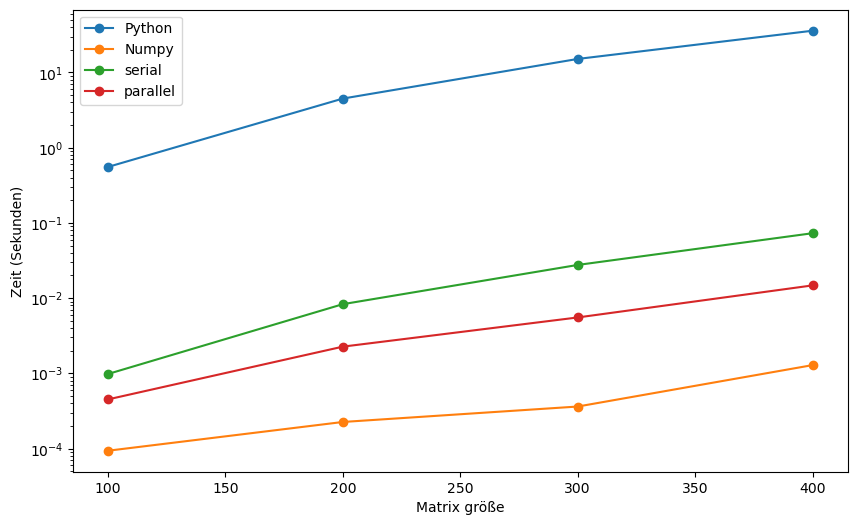

In [18]:
import matplotlib.pyplot as plt
import numba as nb
# 1.1 + 1.2

# JIT-compiled serial
@jit
def matrix_product_serial(mat_a, mat_b):
    m = mat_a.shape[0]
    n = mat_b.shape[1]
    assert(mat_a.shape[1] == mat_b.shape[0])
    ncol = mat_a.shape[1]
    mat_c = np.zeros((m, n), dtype=np.float64)
    for row_ind in range(m):
        for col_ind in range(n):
            for k in range(ncol):
                mat_c[row_ind, col_ind] += mat_a[row_ind, k] * mat_b[k, col_ind]
    return mat_c

#parallel version
@jit(parallel=True)
def matrix_product_parallel(mat_a, mat_b):
    m = mat_a.shape[0]
    n = mat_b.shape[1]
    assert(mat_a.shape[1] == mat_b.shape[0])
    ncol = mat_a.shape[1]
    mat_c = np.zeros((m, n), dtype=np.float64)
    for row_ind in nb.prange(m):
        for col_ind in range(n):
            for k in range(ncol):
                mat_c[row_ind, col_ind] += mat_a[row_ind, k] * mat_b[k, col_ind]
    return mat_c


t_python = []
t_numpy = []
t_serial = []
t_parallel = []

for i in [100,200,300,400]:
    a_test = np.random.randn(i, i)
    b_test = np.random.randn(i, i)

    timeit_result = %timeit -o matrix_product(a_test, b_test)
    t_python.append(timeit_result.best)

    timeit_result = %timeit -o a_test @ b_test
    t_numpy.append(timeit_result.best)

    timeit_result = %timeit -o matrix_product_serial(a_test, b_test)
    t_serial.append(timeit_result.best)
    
    timeit_result = %timeit -o matrix_product_parallel(a_test, b_test)
    t_parallel.append(timeit_result.best)

plt.figure(figsize=(10, 6))
plt.plot([100, 200, 300, 400], t_python, label='Python', marker='o')
plt.plot([100, 200, 300, 400], t_numpy, label='Numpy', marker='o')
plt.plot([100, 200, 300, 400], t_serial, label='serial', marker='o')
plt.plot([100, 200, 300, 400], t_parallel, label='parallel', marker='o')
plt.xlabel('Matrix größe')
plt.ylabel('Zeit (Sekunden)')
plt.legend()
plt.yscale('log')
plt.show()

In [21]:
#1.3
for i in [100,200,300,400]:
    a_test = np.random.randn(i, i)
    b_test = np.random.randn(i, i)
    b_fortran = np.asfortranarray(b_test)
    timeit_result_parallel_fortran = %timeit -o matrix_product_numba_parallel(a_test, b_fortran)
    print(f"{timeit_result_parallel_fortran.best}")

364 μs ± 8.73 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
0.0003503623999995398
2.12 ms ± 241 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
0.0018403649000001679
5.93 ms ± 456 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
0.00541667100000268
14.3 ms ± 1.29 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
0.013031811999999263
